# 5.1.6 Model 6: K-Nearest Neighbors (KNN) Regressor

Trained on `X_train_scaled.csv` (log1p-transformed numeric features, per Section 3.11.2) since KNN is distance-based and therefore scale-sensitive, same reasoning as Linear Regression, Ridge, and SVR.

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import make_scorer
import sys, os
sys.path.append(os.path.dirname(os.path.abspath('__file__')))
from model_utils import evaluate_model, cross_validate_model

MODELLING_DIR = os.path.join("..", "data", "modelling")
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

X_train = pd.read_csv(os.path.join(MODELLING_DIR, "X_train_scaled.csv"))
X_test = pd.read_csv(os.path.join(MODELLING_DIR, "X_test_scaled.csv"))
y_train = pd.read_csv(os.path.join(MODELLING_DIR, "y_train.csv"))["price"]
y_test = pd.read_csv(os.path.join(MODELLING_DIR, "y_test.csv"))["price"]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")


X_train: (3004, 51) | X_test: (751, 51)


## Additional Feature Standardisation

Section 3.11 applies log1p to reduce skewness within individual features, but this does not equalise the *scale* of different features relative to each other - after log1p, Total Units still has a wider spread than Bathroom, so a raw feature difference on Total Units would dominate a raw feature difference on Bathroom in any distance calculation, regardless of which is actually more predictive of price. Since KNN selects neighbours purely by distance, an additional `StandardScaler` step is needed on top of the log1p-scaled data.

Rather than fitting one `StandardScaler` on the whole of `X_train` before tuning, the scaler is wrapped together with `KNeighborsRegressor` inside a single `sklearn.pipeline.Pipeline`. This keeps the scaler's mean/std computation properly nested inside cross-validation: for every fold below, the scaler is fit only on that fold's training portion and applied to its validation portion, so no validation row ever influences its own scaling statistics (the same train-only-fit principle Section 3.9-3.11 applies to encoding and imputation, extended one level deeper into CV). The final model (fit on the complete `X_train` via `GridSearchCV`'s `refit=True`) still fits its own scaler on all of `X_train`, exactly as before - only the CV-time behaviour changes.

## Hyperparameter Tuning

The model was tuned using `GridSearchCV` with 5-fold cross-validation on `X_train`. `GridSearchCV` searches over a `Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsRegressor())])` rather than a bare `KNeighborsRegressor`, so the scaler above is refit on each fold's training portion only (see previous section). Since `y_train` is `log(price)`, a plain RMSE scorer would rank configurations by log-scale error - because `exp()` is a non-linear transform, this does not guarantee the same ranking as RM-scale RMSE, which Section 1.8 defines as this project's primary metric. `GridSearchCV` is therefore configured with a custom scorer that converts predictions back to RM before computing RMSE, using the same fold split (`KFold(n_splits=5, shuffle=True, random_state=42)`) as the CV reported later in this section, so the two are directly comparable. `X_test` is not used anywhere in this tuning section.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def rm_scale_rmse(y_true_log, y_pred_log):
    y_true_rm = np.exp(y_true_log)
    y_pred_rm = np.exp(y_pred_log)
    return np.sqrt(np.mean((y_true_rm - y_pred_rm) ** 2))

rm_rmse_scorer = make_scorer(rm_scale_rmse, greater_is_better=False)
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42)

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor()),
])

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 10, 15, 20, 30],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 1.5, 2, 3],
}

grid_search = GridSearchCV(
    knn_pipeline,
    param_grid,
    scoring=rm_rmse_scorer,
    cv=cv_splitter,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV score (RM-scale RMSE): RM {-grid_search.best_score_:,.0f}")


Best params: {'knn__n_neighbors': 3, 'knn__p': 2, 'knn__weights': 'distance'}
Best CV score (RM-scale RMSE): RM 208,255


## 5-fold Cross-Validation

Run on `X_train` only (`X_test` stays untouched), using the same fold split as the search above, so the CV score `GridSearchCV` selected on and the full metric breakdown here are directly comparable. `cross_validate_model` clones `grid_search.best_estimator_` (the tuned Pipeline) for each fold, so the scaler is re-fit per fold here too - the hyperparameters are fixed at this point (no further tuning), only the metric breakdown is new.

In [3]:
cv_results = cross_validate_model(
    grid_search.best_estimator_,
    X_train, y_train, n_splits=5,
)


5-fold CV (mean +/- std):
  RMSE:  RM 208,292 +/- 21,242  (59.2% of median price)
  MAE:   RM 97,020 +/- 4,368
  MAPE:  22.6% +/- 1.4%
  R2:    0.5892 +/- 0.0153


## Train Final Model

`GridSearchCV` was run with its default `refit=True`, so it already retrained a model on the full `X_train` using the best-found configuration (`grid_search.best_estimator_`). That model is reused directly here instead of manually reconstructing and refitting an identical one. `X_test` is not used in any hyperparameter decision - it is touched only once, below, for the final held-out evaluation.

In [4]:
final_params = grid_search.best_params_
model = grid_search.best_estimator_

print("Final params:", final_params)
print("Model ready (reused from GridSearchCV's refit=True).")


Final params: {'knn__n_neighbors': 3, 'knn__p': 2, 'knn__weights': 'distance'}
Model ready (reused from GridSearchCV's refit=True).


## Evaluate
Metrics computed on both train and test sets - the gap between them is needed for Section 6.2's overfitting/underfitting analysis.

In [5]:
train_metrics = evaluate_model(model, X_train, y_train, label="Train")
print()
test_metrics = evaluate_model(model, X_test, y_test, label="Test")


Train RMSE:  RM 6,749  (1.9% of median price)
Train MAE:   RM 1,135
Train MAPE:  0.3%
Train R2:    0.9996

Test RMSE:  RM 190,051  (52.8% of median price)
Test MAE:   RM 95,110
Test MAPE:  20.4%
Test R2:    0.6718


## Sanity check: permutation importance vs EDA (Section 4.5.2)
KNN has no `coef_`/`feature_importances_` (predictions are based purely on distances to neighbouring points), so permutation importance is used instead: each feature is shuffled and the resulting drop in test R² is measured. Section 4.5.2 ranked Property Size, Bathroom, Parking Lot, and the Has_Gymnasium/Has_Swimming_Pool amenities as the strongest numerical correlates of price - this checks whether KNN's learned importances broadly agree.

In [6]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    model, X_test, y_test, scoring="r2", n_repeats=10, random_state=42, n_jobs=-1,
)
importance_table = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
print("Top 15 features by permutation importance (mean R2 drop):")
print(importance_table.head(15))


Top 15 features by permutation importance (mean R2 drop):
Property Size                     0.053433
PropertyType_Flat                 0.037643
Bathroom                          0.034282
State_Sabah                       0.030981
State_Unknown                     0.019410
PropertyType_Service_Residence    0.019121
PropertyType_Condominium          0.015502
State_Penang                      0.013661
State_Negeri_Sembilan             0.012581
Total Units                       0.012536
State_Sarawak                     0.012247
State_Putrajaya                   0.012046
Property Age                      0.010379
# of Floors                       0.010106
State_Kuala_Lumpur                0.009730
dtype: float64


## Save Trained Model
`model` is the full Pipeline (StandardScaler + KNN), so this single file is enough for the Streamlit prototype (Section 8) to load and predict directly, without retraining or managing a separate scaler file.

In [7]:
import joblib
model_path = os.path.join(MODEL_DIR, "knn_model.pkl")
joblib.dump(model, model_path)
print(f"Model saved to {model_path}")

Model saved to ..\models\knn_model.pkl


## Hyperparameter Sensitivity Visualizations (Diagnostic)

The figures below sweep each hyperparameter individually, holding the other two fixed at the values already selected by GridSearchCV, evaluated using 5-fold CV RMSE on X_train. They illustrate why the selected configuration is a sound choice; they are not used to select it (see Hyperparameter Tuning above). X_test is not used anywhere below.

## Effect of n_neighbors

5-fold CV (mean +/- std):
  RMSE:  RM 217,082 +/- 28,895  (61.7% of median price)
  MAE:   RM 97,664 +/- 5,069
  MAPE:  22.3% +/- 1.3%
  R2:    0.5564 +/- 0.0255
5-fold CV (mean +/- std):
  RMSE:  RM 220,451 +/- 30,885  (62.7% of median price)
  MAE:   RM 98,225 +/- 6,581
  MAPE:  22.2% +/- 1.5%
  R2:    0.5435 +/- 0.0251
5-fold CV (mean +/- std):
  RMSE:  RM 226,335 +/- 35,064  (64.3% of median price)
  MAE:   RM 99,707 +/- 7,507
  MAPE:  22.3% +/- 1.4%
  R2:    0.5195 +/- 0.0438
5-fold CV (mean +/- std):
  RMSE:  RM 232,962 +/- 36,823  (66.2% of median price)
  MAE:   RM 101,259 +/- 7,785
  MAPE:  22.5% +/- 1.5%
  R2:    0.4913 +/- 0.0480
5-fold CV (mean +/- std):
  RMSE:  RM 236,550 +/- 38,818  (67.2% of median price)
  MAE:   RM 102,282 +/- 8,298
  MAPE:  22.7% +/- 1.6%
  R2:    0.4764 +/- 0.0529
5-fold CV (mean +/- std):
  RMSE:  RM 240,465 +/- 39,249  (68.4% of median price)
  MAE:   RM 104,139 +/- 8,608
  MAPE:  23.1% +/- 1.7%
  R2:    0.4590 +/- 0.0535


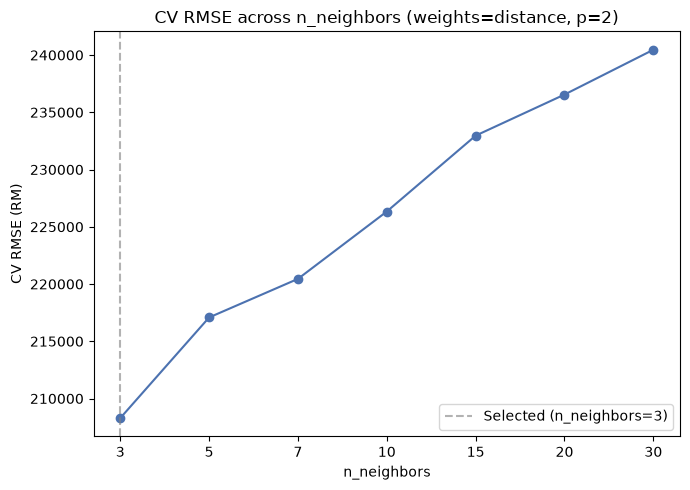

n_neighbors=3: CV RMSE=RM208,292
n_neighbors=5: CV RMSE=RM217,082
n_neighbors=7: CV RMSE=RM220,451
n_neighbors=10: CV RMSE=RM226,335
n_neighbors=15: CV RMSE=RM232,962
n_neighbors=20: CV RMSE=RM236,550
n_neighbors=30: CV RMSE=RM240,465


In [8]:
import matplotlib.pyplot as plt

best = grid_search.best_params_
k_candidates = [3, 5, 7, 10, 15, 20, 30]
cv_rmse_by_k = []

for k in k_candidates:
    if k == best["knn__n_neighbors"]:
        cv_rmse_by_k.append(cv_results["mean"]["RMSE"])
        continue
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k, weights=best["knn__weights"], p=best["knn__p"])),
    ])
    cv = cross_validate_model(pipeline, X_train, y_train, n_splits=5)
    cv_rmse_by_k.append(cv["mean"]["RMSE"])

k_labels = [str(k) for k in k_candidates]

plt.figure(figsize=(7, 5))
plt.plot(k_labels, cv_rmse_by_k, marker="o", color="#4c72b0")
plt.axvline(x=k_labels.index(str(best["knn__n_neighbors"])), color="grey", linestyle="--", alpha=0.6, label=f"Selected (n_neighbors={best['knn__n_neighbors']})")
plt.xlabel("n_neighbors")
plt.ylabel("CV RMSE (RM)")
plt.title(f"CV RMSE across n_neighbors (weights={best['knn__weights']}, p={best['knn__p']})")
plt.legend()
plt.tight_layout()
plt.show()

for k, r in zip(k_candidates, cv_rmse_by_k):
    print(f"n_neighbors={k}: CV RMSE=RM{r:,.0f}")


## Effect of p

5-fold CV (mean +/- std):
  RMSE:  RM 216,590 +/- 34,490  (61.6% of median price)
  MAE:   RM 95,042 +/- 7,527
  MAPE:  21.8% +/- 1.5%
  R2:    0.5607 +/- 0.0421
5-fold CV (mean +/- std):
  RMSE:  RM 211,888 +/- 26,727  (60.3% of median price)
  MAE:   RM 96,676 +/- 5,606
  MAPE:  22.3% +/- 1.4%
  R2:    0.5773 +/- 0.0157
5-fold CV (mean +/- std):
  RMSE:  RM 212,445 +/- 27,319  (60.4% of median price)
  MAE:   RM 99,869 +/- 4,712
  MAPE:  23.4% +/- 1.3%
  R2:    0.5738 +/- 0.0344


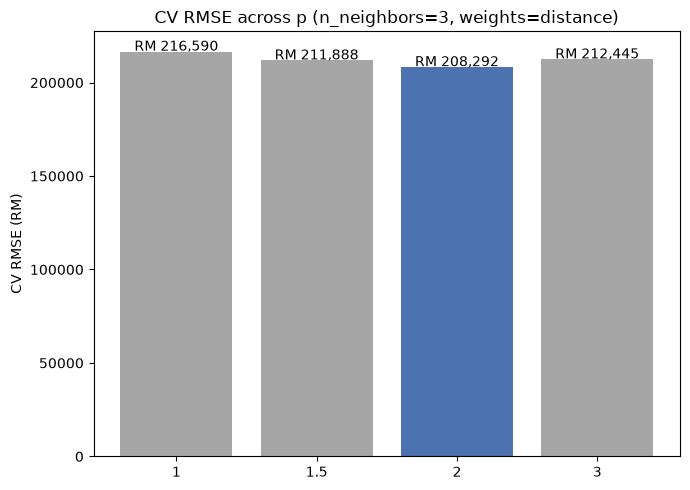

p=1: CV RMSE=RM216,590
p=1.5: CV RMSE=RM211,888
p=2: CV RMSE=RM208,292
p=3: CV RMSE=RM212,445


In [9]:
best = grid_search.best_params_
p_candidates = [1, 1.5, 2, 3]
cv_rmse_by_p = []

for p in p_candidates:
    if p == best["knn__p"]:
        cv_rmse_by_p.append(cv_results["mean"]["RMSE"])
        continue
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=best["knn__n_neighbors"], weights=best["knn__weights"], p=p)),
    ])
    cv = cross_validate_model(pipeline, X_train, y_train, n_splits=5)
    cv_rmse_by_p.append(cv["mean"]["RMSE"])

colors = ["#4c72b0" if p == best["knn__p"] else "#a6a6a6" for p in p_candidates]

plt.figure(figsize=(7, 5))
plt.bar([str(p) for p in p_candidates], cv_rmse_by_p, color=colors)
plt.ylabel("CV RMSE (RM)")
plt.title(f"CV RMSE across p (n_neighbors={best['knn__n_neighbors']}, weights={best['knn__weights']})")
for i, v in enumerate(cv_rmse_by_p):
    plt.text(i, v + 500, f"RM {v:,.0f}", ha="center")
plt.tight_layout()
plt.show()

for p, r in zip(p_candidates, cv_rmse_by_p):
    print(f"p={p}: CV RMSE=RM{r:,.0f}")


## Effect of weights

5-fold CV (mean +/- std):
  RMSE:  RM 211,152 +/- 20,774  (60.1% of median price)
  MAE:   RM 102,050 +/- 3,850
  MAPE:  23.9% +/- 1.5%
  R2:    0.5775 +/- 0.0181


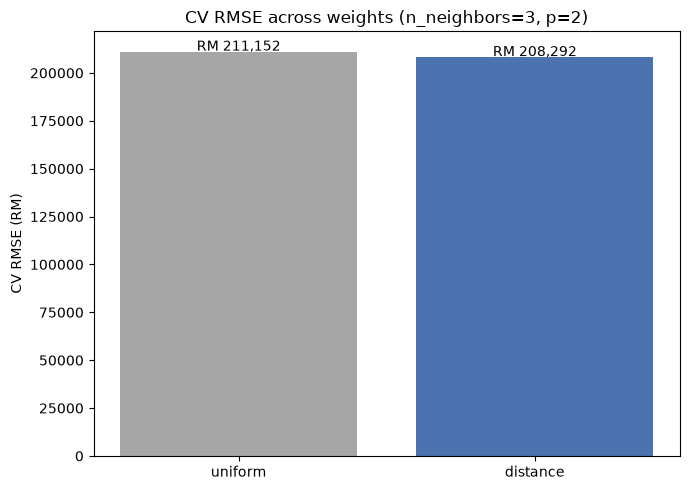

weights=uniform: CV RMSE=RM211,152
weights=distance: CV RMSE=RM208,292


In [10]:
best = grid_search.best_params_
weight_candidates = ["uniform", "distance"]
cv_rmse_by_w = []

for w in weight_candidates:
    if w == best["knn__weights"]:
        cv_rmse_by_w.append(cv_results["mean"]["RMSE"])
        continue
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=best["knn__n_neighbors"], weights=w, p=best["knn__p"])),
    ])
    cv = cross_validate_model(pipeline, X_train, y_train, n_splits=5)
    cv_rmse_by_w.append(cv["mean"]["RMSE"])

colors = ["#4c72b0" if w == best["knn__weights"] else "#a6a6a6" for w in weight_candidates]

plt.figure(figsize=(7, 5))
plt.bar(weight_candidates, cv_rmse_by_w, color=colors)
plt.ylabel("CV RMSE (RM)")
plt.title(f"CV RMSE across weights (n_neighbors={best['knn__n_neighbors']}, p={best['knn__p']})")
for i, v in enumerate(cv_rmse_by_w):
    plt.text(i, v + 500, f"RM {v:,.0f}", ha="center")
plt.tight_layout()
plt.show()

for w, r in zip(weight_candidates, cv_rmse_by_w):
    print(f"weights={w}: CV RMSE=RM{r:,.0f}")
